In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

## ETAPE 1 

#  FUSION DES CSV 

In [ ]:
# dossier contenant les CSV
csv_path = "Csv_files/*.csv"

dfs = []

for file in glob.glob(csv_path):
    df = pd.read_csv(file)
    
    # extraire le type d’attaque depuis le nom du fichier
    attack_type = os.path.basename(file).replace(".csv", "")
    df["attack_type"] = attack_type
    
    dfs.append(df)

# fusion finale
df_csv_global = pd.concat(dfs, ignore_index=True)

# sauvegarde
df_csv_global.to_csv("CSV_GLOBAL_ATTACKS.csv", index=False)

print("Fusion CSV terminée :", df_csv_global.shape)


Fusion CSV terminée : (648350, 8)


In [ ]:
#  VérifiCATION DES PERTES DE DONNEES 

csv_path = "Csv_files/*.csv"

total_rows_original = 0

for f in glob.glob(csv_path):
    df = pd.read_csv(f)
    print(f, "→ lignes :", len(df))
    total_rows_original += len(df)

print("Total lignes fichiers originaux :", total_rows_original)


C:\Users\DELL\Documents\M1\PythonforIA\web\Csv_files\attack_web_backdoor-upload_edge1.csv → lignes : 18581
C:\Users\DELL\Documents\M1\PythonforIA\web\Csv_files\attack_web_command-injection_edge1.csv → lignes : 73002
C:\Users\DELL\Documents\M1\PythonforIA\web\Csv_files\attack_web_sql-injection-blind_edge1.csv → lignes : 433404
C:\Users\DELL\Documents\M1\PythonforIA\web\Csv_files\attack_web_sql-injection_edge1.csv → lignes : 37233
C:\Users\DELL\Documents\M1\PythonforIA\web\Csv_files\attack_web_xss_edge1.csv → lignes : 86130
Total lignes fichiers originaux : 648350


In [6]:
#Vérifier qu’aucune colonne n’est vide
df_csv_global.isnull().sum().sort_values(ascending=False)

No.            0
Time           0
Source         0
Destination    0
Protocol       0
Length         0
Info           0
attack_type    0
dtype: int64

# FUSION DES JSON

In [ ]:
json_path = "Json_files/*.json"
dfs = []

for file in glob.glob(json_path):
    df = pd.read_json(file, lines=True)
    
    # aplatir les objets
    general = pd.json_normalize(df["general"])
    mqtt = pd.json_normalize(df["mqtt"])
    
    df_flat = pd.concat(
        [df.drop(columns=["general", "mqtt"]).reset_index(drop=True),
         general.reset_index(drop=True),
         mqtt.reset_index(drop=True)],
        axis=1
    )
    
    # type d’attaque depuis le nom du fichier
    attack_type = os.path.basename(file).replace(".json", "")
    df_flat["attack_type"] = attack_type
    
    dfs.append(df_flat)

# fusion finale
df_json_global = pd.concat(dfs, ignore_index=True)

# sauvegarde
df_json_global.to_csv("JSON_GLOBAL_ATTACKS_FLAT.csv", index=False)

print("Fusion JSON terminée :", df_json_global.shape)


Fusion JSON terminée : (56242, 14)


# Vérifier la lecture du JSON

In [ ]:


json_path = "Json_files/*.json"

total_json_rows = 0

for f in glob.glob(json_path):
    df = pd.read_json(f, lines=True)
    print(os.path.basename(f), "→ lignes lues :", len(df))
    total_json_rows += len(df)

print("Total lignes JSON originales :", total_json_rows)


attack_web_backdoor-upload_edge1.json → lignes lues : 4215
attack_web_command-injection_edge1.json → lignes lues : 20028
attack_web_sql-injection-blind_edge1.json → lignes lues : 19907
attack_web_sql-injection_edge1.json → lignes lues : 7723
attack_web_xss_edge1.json → lignes lues : 4369
Total lignes JSON originales : 56242


# Vérifier perte pendant aplatissement

In [12]:
for f in glob.glob(json_path):
    df = pd.read_json(f, lines=True)

    n_before = len(df)

    general = pd.json_normalize(df["general"])
    mqtt = pd.json_normalize(df["mqtt"])

    df_flat = pd.concat(
        [df.drop(columns=["general", "mqtt"]).reset_index(drop=True),
         general.reset_index(drop=True),
         mqtt.reset_index(drop=True)],
        axis=1
    )

    n_after = len(df_flat)

    print(os.path.basename(f), "avant:", n_before, "après aplatissement:", n_after)


attack_web_backdoor-upload_edge1.json avant: 4215 après aplatissement: 4215
attack_web_command-injection_edge1.json avant: 20028 après aplatissement: 20028
attack_web_sql-injection-blind_edge1.json avant: 19907 après aplatissement: 19907
attack_web_sql-injection_edge1.json avant: 7723 après aplatissement: 7723
attack_web_xss_edge1.json avant: 4369 après aplatissement: 4369


In [13]:
#Vérifier qu’aucune colonne n’est vide
df_json_global.isnull().sum().sort_values(ascending=False)

@timestamp       0
device_name      0
application      0
ip               0
full_id          0
mac              0
retained         0
qos              0
message_value    0
topic            0
message_id       0
message_type     0
duplicate        0
attack_type      0
dtype: int64

Ce n’est une perte mais il se peut que le champ message_value n’existe pas dans certaines lignes JSON ou la clé existe mais contient null.

# ETAPE 2

# ANALYSE  DE CSV 

⏳ Analyse...

📊 Résultats détectés :
Attack_Type
SQL Injection            29660
Command Injection         2440
XSS                        707
Blind SQL Injection        138
Web Backdoor / Upload        2
Name: count, dtype: int64


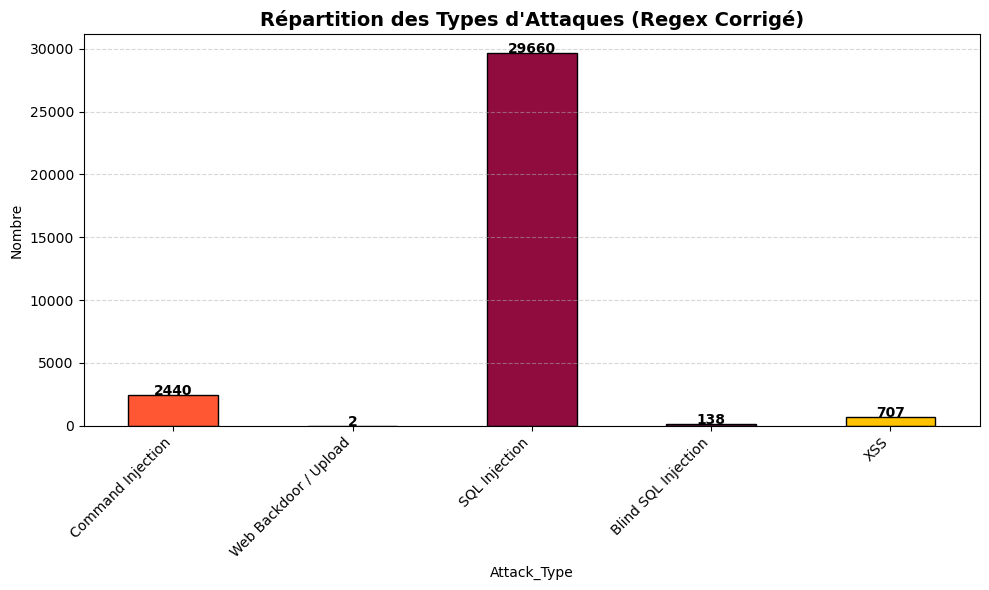

In [ ]:

from urllib.parse import unquote

FILENAME = "CSV_GLOBAL_ATTACKS.csv"

# Chargement
df = pd.read_csv(FILENAME, low_memory=False)
df["Info"] = df["Info"].fillna("").astype(str)

def classify_attack(raw_info):
    text = unquote(raw_info).lower()

    # 1. Blind SQL Injection
    if re.search(r"\b(sleep|benchmark|pg_sleep|waitfor\s+delay)\s*\(", text):
        return "Blind SQL Injection"

    # 2. SQL Injection (Classique)
    if re.search(r"union\s+(all\s+)?select|information_schema|('|\")\s*(or|and)\s*('?1'?='?1?|\d+=\d+)|--\s|#", text):
        return "SQL Injection"

    # 3. XSS
    if re.search(r"<script|javascript:|vbscript:|\bon(load|error|mouseover|click)=", text):
        return "XSS"

    # 4. Command Injection (CORRIGÉ ET ÉLARGI)
    if re.search(r"(;|\||&&|\$|\(|`|=|\s)\s*\b(whoami|id|uname|cat|ls|pwd|wget|curl|nc|bash|sh)\b", text) or \
       re.search(r"/bin/(sh|bash)", text):
        return "Command Injection"

    # 5. Web Backdoor / Upload
    if re.search(r"\.(php|jsp|asp|phtml|sh)$", text) or re.search(r"\b(system|exec|passthru|shell_exec|eval|base64_decode)\s*\(", text):
        return "Web Backdoor / Upload"

    return "Normal Traffic"

# Application
print("⏳ Analyse...")
df["Attack_Type"] = df["Info"].apply(classify_attack)
attacks_only = df[df["Attack_Type"] != "Normal Traffic"]

# Résultats
counts = attacks_only["Attack_Type"].value_counts()
print("\n📊 Résultats détectés :")
print(counts)

# Graphique
if not counts.empty:
    all_categories = ["Command Injection", "Web Backdoor / Upload", "SQL Injection", "Blind SQL Injection", "XSS"]
    
    # Réaligner les comptes avec toutes les catégories (met 0 si absent)
    counts = counts.reindex(all_categories, fill_value=0)
    
    plt.figure(figsize=(10, 6))
    colors = ['#FF5733', '#C70039', '#900C3F', '#581845', '#FFC300']
    
    ax = counts.plot(kind='bar', color=colors, edgecolor='black')
    plt.title('Répartition des Types d\'Attaques (Regex Corrigé)', fontsize=14, fontweight='bold')
    plt.ylabel('Nombre')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Affichage des valeurs
    for i, v in enumerate(counts):
        if v > 0:
            ax.text(i, v + 0.1, str(int(v)), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("⚠ Aucune attaque détectée .")

# 2 - ANALYSE DES CSV (JSON)

In [ ]:


# 1. Charger les données
df = pd.read_csv('JSON_GLOBAL_ATTACKS_FLAT.csv')

# 2. Dictionnaire des signatures pour les 5 types d'attaques
signatures = {
    "Command Injection": [';', '&&', '|', '/bin/sh', 'whoami', 'cat /etc/passwd'],
    "SQL Injection": ["' OR 1=1", "UNION SELECT", "DROP TABLE", "INSERT INTO"],
    "Blind SQL Injection": ["SLEEP(", "BENCHMARK(", "WAITFOR DELAY", "AND 1=1"],
    "XSS (Cross-Site Scripting)": ["<script>", "alert(", "onerror=", "<img>", "href="],
    "Web Backdoor / Upload": ["<?php", "eval(", "base64_decode", "shell_exec", ".php", ".sh"]
}

print("### ANALYSE DES INDICES DIRECTS DANS LES MESSAGES IOT ###\n")

total_global = 0

for attack, sigs in signatures.items():
    # Correction cruciale : on utilise re.escape pour que les '(' ne soient pas traitées comme des commandes
    pattern_protege = '|'.join([re.escape(s) for s in sigs])
    
    # Recherche dans message_value (on convertit en string pour éviter les erreurs de type)
    mask = df['message_value'].astype(str).str.contains(pattern_protege, na=False, case=False)
    count = len(df[mask])
    total_global += count
    
    print(f"Indices directs pour {attack} : {count}")


### ANALYSE DES INDICES DIRECTS DANS LES MESSAGES IOT ###

Indices directs pour Command Injection : 0
Indices directs pour SQL Injection : 0
Indices directs pour Blind SQL Injection : 0
Indices directs pour XSS (Cross-Site Scripting) : 0
Indices directs pour Web Backdoor / Upload : 0


Aucun indice direct n'a été trouvé dans les messages IoT, confirmant que la détection doit s'appuyer sur d'autres types de données (Réseau/Système) ou sur l'analyse comportementale (Anomalies de flux)."

# 2 - La Corrélation Multi-Sources (Réseau + IoT)

Puisque l'attaque est visible dans le fichier Réseau (ORIGINE PCAP) mais non pas dans le fichier IoT (JSON), l'étape suivante est de les lier.

-Action : Aligner les horodatages (timestamps) des deux fichiers pour voir ce qui se passe sur le réseau au moment précis où un capteur envoie une donnée "anormale" étiquetée "Attaque".

-Objectif : Créer un dataset "hybride" qui contient à la fois la télémétrie du capteur et les métriques réseau (latence, taille des paquets).

Alors on va aligner le fichier réseau sur le fichier IoT.
Dans merge_asof, on utilise l'argument by pour forcer cette correspondance exacte.

-> on='@timestamp' : On cherche le temps le plus proche (approximatif).

-> by='attack_type' : On exige que le type d'attaque soit strictement identique.

!!!!! On va dire à Python : "Prends le début de l'attaque réseau et colle-le sur le début de l'attaque IoT".

In [ ]:

# 1. Chargement
df_iot = pd.read_csv('JSON_GLOBAL_ATTACKS_FLAT.csv')
df_net = pd.read_csv('CSV_GLOBAL_ATTACKS.csv')

# 2. Préparation IoT (Date réelle)
df_iot['@timestamp'] = pd.to_datetime(df_iot['@timestamp']).dt.tz_localize(None)

# 3. Préparation Réseau (On garde le temps en secondes brutes d'abord)
# On prend la colonne 'Time' comme FLOTTANT (chiffre)
col_time_net = 'Time' if 'Time' in df_net.columns else 'frame.time'
# On force en numérique (secondes) pour éviter le bug 1970
df_net['relative_time'] = pd.to_numeric(df_net[col_time_net], errors='coerce').fillna(0)

print("DÉBUT DE LA SYNCHRONISATION ")

dfs_aligned = []

# 4. ALIGNEMENT INTELLIGENT PAR TYPE D'ATTAQUE
for attack in df_iot['attack_type'].unique():
    print(f"Traitement de : {attack}")
    
    # On prend les données IoT et Net de cette attaque spécifique
    subset_iot = df_iot[df_iot['attack_type'] == attack]
    subset_net = df_net[df_net['attack_type'] == attack].copy()
    
    if subset_net.empty:
        print(f" -> Attention : Aucune donnée réseau pour {attack}")
        continue
        
    # TROUVER LE POINT DE DÉPART (L'ANCRE)
    # On dit que le temps 0 du réseau = le premier message IoT de cette attaque
    start_time_iot = subset_iot['@timestamp'].min()
    
    # On recrée la date réseau : Date de départ IoT + Secondes du fichier réseau
    subset_net['@timestamp'] = start_time_iot + pd.to_timedelta(subset_net['relative_time'], unit='s')
    
    dfs_aligned.append(subset_net)

# 5. RECONSTRUCTION DU FICHIER RÉSEAU CORRIGÉ
if dfs_aligned:
    df_net_fixed = pd.concat(dfs_aligned)
    
    # Tri final
    df_iot = df_iot.sort_values('@timestamp')
    df_net_fixed = df_net_fixed.sort_values('@timestamp')
    
    print("\nDates corrigées (Réseau) :", df_net_fixed['@timestamp'].min(), "à", df_net_fixed['@timestamp'].max())

    # 6. FUSION FINALE 
    df_enriched = pd.merge_asof(
        df_iot,
        df_net_fixed[['@timestamp', 'attack_type', 'Length', 'Protocol', 'Info']],
        on='@timestamp',
        by='attack_type',
        direction='nearest',
        tolerance=pd.Timedelta("10s") 
    )

    # Vérification des résultats
    missing = df_enriched['Length'].isna().sum()
    total = len(df_enriched)
    print(f"\nRÉSULTAT FUSION : {total - missing} lignes matchées sur {total}")
    print(df_enriched[['@timestamp', 'attack_type', 'Length']].head())
    
    df_enriched.to_csv('DATASET_FINAL_SYNC.csv', index=False)
else:
    print("Erreur : Impossible d'aligner les données.")

DÉBUT DE LA SYNCHRONISATION 
Traitement de : attack_web_backdoor-upload_edge1
Traitement de : attack_web_command-injection_edge1
Traitement de : attack_web_sql-injection-blind_edge1
Traitement de : attack_web_sql-injection_edge1
Traitement de : attack_web_xss_edge1

Dates corrigées (Réseau) : 2025-01-28 20:00:05.191000 à 2025-02-04 21:43:39.111962

RÉSULTAT FUSION : 56242 lignes matchées sur 56242
               @timestamp           attack_type  Length
0 2025-01-28 20:00:05.191  attack_web_xss_edge1      72
1 2025-01-28 20:00:05.195  attack_web_xss_edge1     230
2 2025-01-28 20:00:05.257  attack_web_xss_edge1     214
3 2025-01-28 20:00:05.480  attack_web_xss_edge1      60
4 2025-01-28 20:00:05.642  attack_web_xss_edge1      73


In [58]:
df_enriched

,@timestamp,device_name,application,ip,full_id,mac,retained,qos,message_value,topic,message_id,message_type,duplicate,attack_type,Length,Protocol,Info
0,2025-01-28 20:00:05.191,ard-w-10,Accelerometer-Gyroscope,192.168.1.19,08:B6:1F:82:EE:44_192.168.1.19_iiot/accelerati...,08:B6:1F:82:EE:44,False,0,"[-0.74, -0.02, 2.0]",iiot/acceleration/xyz,0,array,False,attack_web_xss_edge1,72,MQTT,Publish Message [iiot/water]
1,2025-01-28 20:00:05.195,ard-w-10,Accelerometer-Gyroscope,192.168.1.19,08:B6:1F:82:EE:44_192.168.1.19_iiot/accelerati...,08:B6:1F:82:EE:44,False,0,Portrait Up,iiot/acceleration/orientation,0,string,False,attack_web_xss_edge1,230,UDP,49154 > 6667 Len=188
2,2025-01-28 20:00:05.257,ard-w-06,Water,192.168.1.11,08:B6:1F:84:66:78_192.168.1.11_iiot/water,08:B6:1F:84:66:78,False,0,1023.0,iiot/water,0,numeric,False,attack_web_xss_edge1,214,UDP,49163 > 6667 Len=172
3,2025-01-28 20:00:05.480,ard-w-08,Steam,192.168.1.13,08:B6:1F:81:D2:CC_192.168.1.13_iiot/steam,08:B6:1F:81:D2:CC,False,0,0.0,iiot/steam,0,numeric,False,attack_web_xss_edge1,60,TCP,52543 > 1883 [ACK] Seq=3 Ack=3 Win=5214 Len=0
4,2025-01-28 20:00:05.642,ard-w-12,Ultrasonic,192.168.1.17,08:B6:1F:82:EE:C4_192.168.1.17_iiot/ultrasonic,08:B6:1F:82:EE:C4,False,0,284.0,iiot/ultrasonic,0,numeric,False,attack_web_xss_edge1,73,MQTT,Publish Message [iiot/vibration]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56237,2025-02-04 21:43:38.789,ard-w-10,Accelerometer-Gyroscope,192.168.1.19,08:B6:1F:82:EE:44_192.168.1.19_iiot/accelerati...,08:B6:1F:82:EE:44,False,0,"[-0.74, -0.02, 2.0]",iiot/acceleration/xyz,0,array,False,attack_web_backdoor-upload_edge1,60,LOOP,No valid function found
56238,2025-02-04 21:43:38.792,ard-w-10,Accelerometer-Gyroscope,192.168.1.19,08:B6:1F:82:EE:44_192.168.1.19_iiot/accelerati...,08:B6:1F:82:EE:44,False,0,Portrait Up,iiot/acceleration/orientation,0,string,False,attack_web_backdoor-upload_edge1,60,LOOP,No valid function found
56239,2025-02-04 21:43:39.033,ard-w-15,Light-Gesture-Proximity,192.168.1.18,8C:AA:B5:8A:A9:B4_192.168.1.18_iiot/light/light,8C:AA:B5:8A:A9:B4,False,0,904.0,iiot/light/light,0,numeric,False,attack_web_backdoor-upload_edge1,73,MQTT,Publish Message [iiot/gas/gas]
56240,2025-02-04 21:43:39.035,ard-w-15,Light-Gesture-Proximity,192.168.1.18,8C:AA:B5:8A:A9:B4_192.168.1.18_iiot/light/prox...,8C:AA:B5:8A:A9:B4,False,0,253.0,iiot/light/proximity,0,numeric,False,attack_web_backdoor-upload_edge1,76,MQTT,Publish Message [iiot/gas/alcohol]


Fusion par colonnes .Ce que est fait : C est gardé le fichier IoT comme "Référence" (Main Table). Pour chaque ligne IoT, on va chercher "l'ami le plus proche" dans le fichier Réseau pour liee ses informations (Length, Protocol).


In [60]:
# le nombre des valeurs manquantes
# isna == isnull
df_enriched.isnull().sum()

@timestamp         0
device_name        0
application        0
ip                 0
full_id            0
mac                0
retained           0
qos                0
message_value    279
topic              0
message_id         0
message_type       0
duplicate          0
attack_type        0
Length             0
Protocol           0
Info               0
dtype: int64